In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

In [14]:
df = pd.read_csv(
"../outputs/cleaned_data/featured_dataset.csv"
)

In [15]:
print(df.head())
print(df.describe())
print(df.info())
print(df.shape)

                           order_id                       customer_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
1  00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
2  000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
3  00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
4  00042b26cf59d7ce69dfabb4e55b4fd9  58dbd0b2d70206bf40e62cd34e84d795   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-09-13 08:59:02  2017-09-13 09:45:35   
1    delivered      2017-04-26 10:53:06  2017-04-26 11:05:13   
2    delivered      2018-01-14 14:33:31  2018-01-14 14:48:30   
3    delivered      2018-08-08 10:00:35  2018-08-08 10:10:18   
4    delivered      2017-02-04 13:57:51  2017-02-04 14:10:13   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-09-19 18:34:16           2017-09-20 23:43:48   
1          2017-05-04 14:35:00           2017-05

In [16]:
df.select_dtypes(
include="number"
).columns

Index(['customer_zip_code_prefix', 'order_item_id', 'price', 'freight_value',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'payment_sequential',
       'payment_installments', 'payment_value', 'review_score',
       'seller_zip_code_prefix', 'order_year', 'order_month', 'order_day',
       'order_week', 'quarter', 'approval_days', 'delivery_days',
       'delivery_delay', 'shipping_percentage'],
      dtype='str')

In [17]:
df.select_dtypes(
include="object"
).columns

C:\Users\Saurabh Prajapati\AppData\Local\Temp\ipykernel_16368\2292861617.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state', 'product_id',
       'seller_id', 'shipping_limit_date', 'product_category_name',
       'payment_type', 'review_id', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'seller_city', 'seller_state',
       'product_category_name_english', 'order_month_name', 'order_day_name',
       'delivery_status', 'installment_type', 'review_category',
       'price_category'],
      dtype='str')

In [18]:
corr = df.corr(
numeric_only=True
)

corr

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,...,order_month,order_day,order_week,quarter,approval_days,is_weekend,delivery_days,delivery_delay,high_value_order,shipping_percentage
customer_zip_code_prefix,1.000000,-0.000528,0.043158,0.225510,0.015804,0.025415,0.020505,0.001620,0.004334,0.011669,...,-0.007064,-0.008577,-0.007930,-0.005818,0.023476,0.001028,0.271288,-0.073860,0.039785,0.120790
order_item_id,-0.000528,1.000000,-0.060459,-0.030694,-0.024155,-0.015059,-0.054455,-0.004326,0.005348,0.029172,...,0.000006,0.017480,0.001883,0.003210,0.033846,-0.016969,-0.016534,-0.026887,0.211493,0.113653
price,0.043158,-0.060459,1.000000,0.415938,0.018026,0.201759,0.052818,0.339367,0.145587,0.224309,...,0.000309,-0.010632,-0.000757,0.000504,0.011775,0.000690,0.061389,-0.003150,0.603471,-0.290833
freight_value,0.225510,-0.030694,0.415938,1.000000,0.022628,0.096506,0.022329,0.611587,0.309672,0.393865,...,0.003654,-0.016249,0.002061,0.003732,0.025666,0.007410,0.212870,-0.040571,0.318334,0.090008
product_name_lenght,0.015804,-0.024155,0.018026,0.022628,1.000000,0.090238,0.145439,0.020736,0.058652,-0.030891,...,0.014196,0.007114,0.014912,0.015663,0.003248,0.000230,-0.003111,0.010794,-0.005867,-0.058112
product_description_lenght,0.025415,-0.015059,0.201759,0.096506,0.090238,1.000000,0.117888,0.063577,0.007468,0.074121,...,-0.014906,-0.002506,-0.014839,-0.014720,0.002552,-0.008059,0.006117,0.007147,0.116525,-0.123837
product_photos_qty,0.020505,-0.054455,0.052818,0.022329,0.145439,0.117888,1.000000,0.021535,0.044662,-0.033464,...,0.010870,-0.000618,0.010708,0.013022,-0.000066,0.003758,-0.026910,0.004008,0.013680,-0.053348
product_weight_g,0.001620,-0.004326,0.339367,0.611587,0.020736,0.063577,0.021535,1.000000,0.463108,0.581970,...,-0.011702,-0.001688,-0.011955,-0.010730,0.009757,0.000954,0.084176,0.009695,0.261145,-0.103848
product_length_cm,0.004334,0.005348,0.145587,0.309672,0.058652,0.007468,0.044662,0.463108,1.000000,0.193398,...,-0.005904,-0.007445,-0.006820,-0.003403,0.006440,0.006863,0.066424,0.008283,0.103457,-0.094707
product_height_cm,0.011669,0.029172,0.224309,0.393865,-0.030891,0.074121,-0.033464,0.581970,0.193398,1.000000,...,0.010590,-0.002605,0.010138,0.010861,0.008872,0.004678,0.068197,-0.001544,0.179804,-0.105659


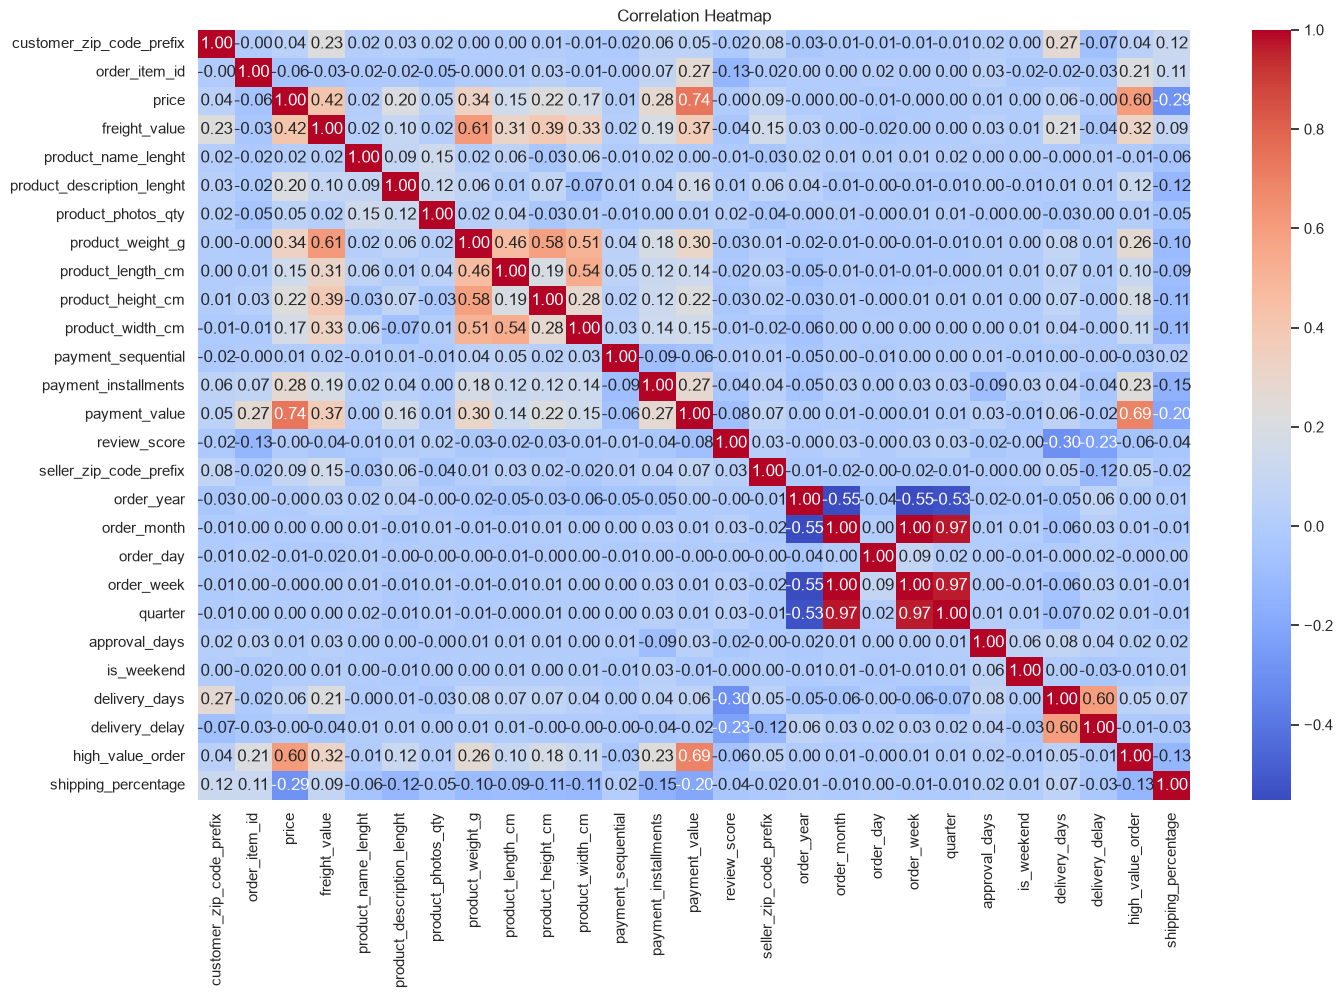

In [19]:
plt.figure(figsize=(16,10))

sns.heatmap(
corr,
annot=True,
fmt=".2f",
cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

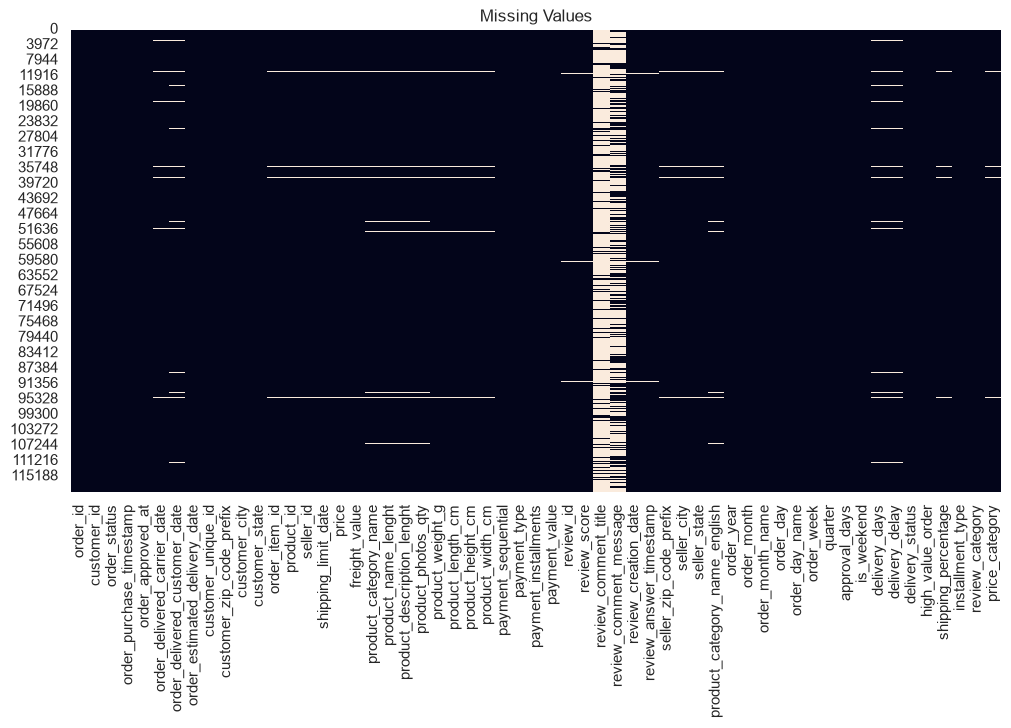

In [21]:
plt.figure(figsize=(12,6))

sns.heatmap(
df.isnull(),
cbar=False
)

plt.title("Missing Values")

plt.show()

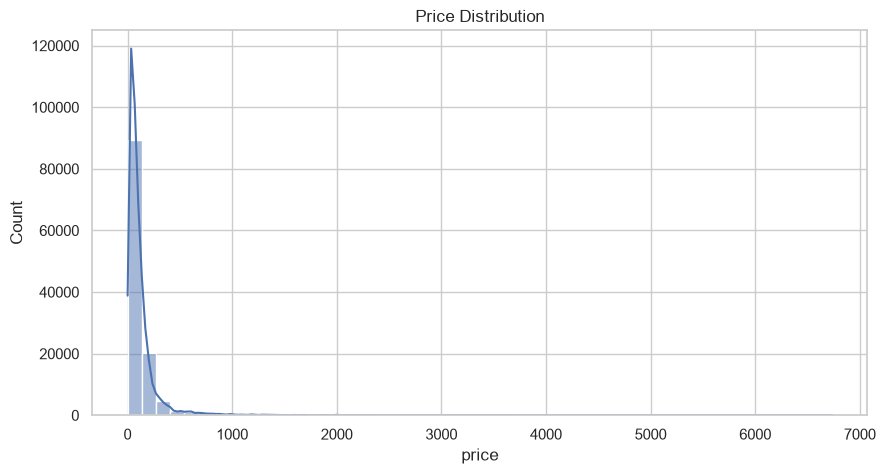

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
df["price"],
bins=50,
kde=True
)

plt.title("Price Distribution")

plt.show()

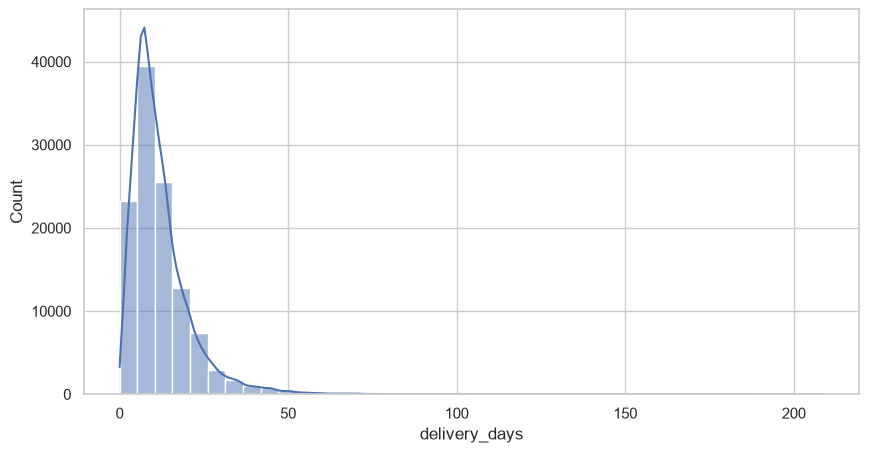

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
df["delivery_days"],
bins=40,
kde=True
)

plt.show()

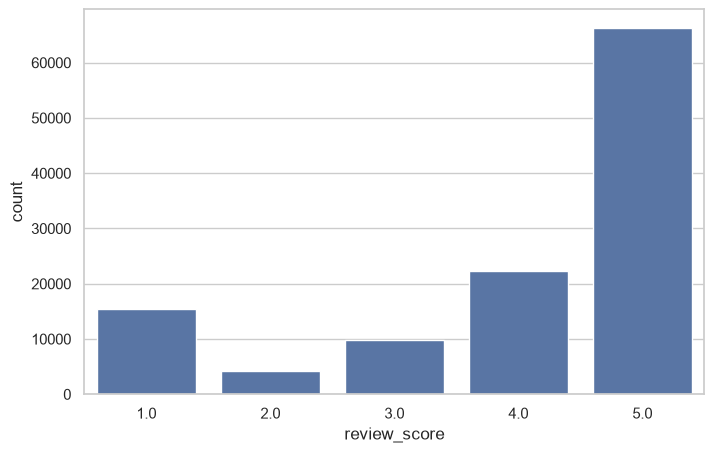

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
x="review_score",
data=df
)

plt.show()

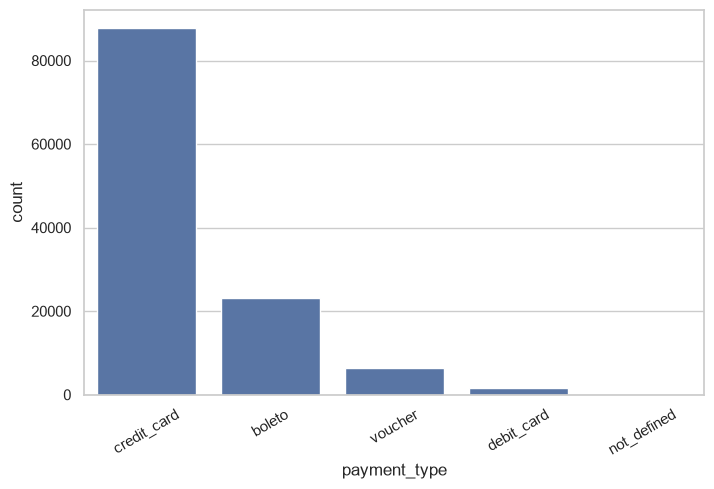

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
x="payment_type",
data=df
)

plt.xticks(rotation=30)

plt.show()

) missing from font(s) Arial.sktop\AI_Retails_Analysis\myvenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


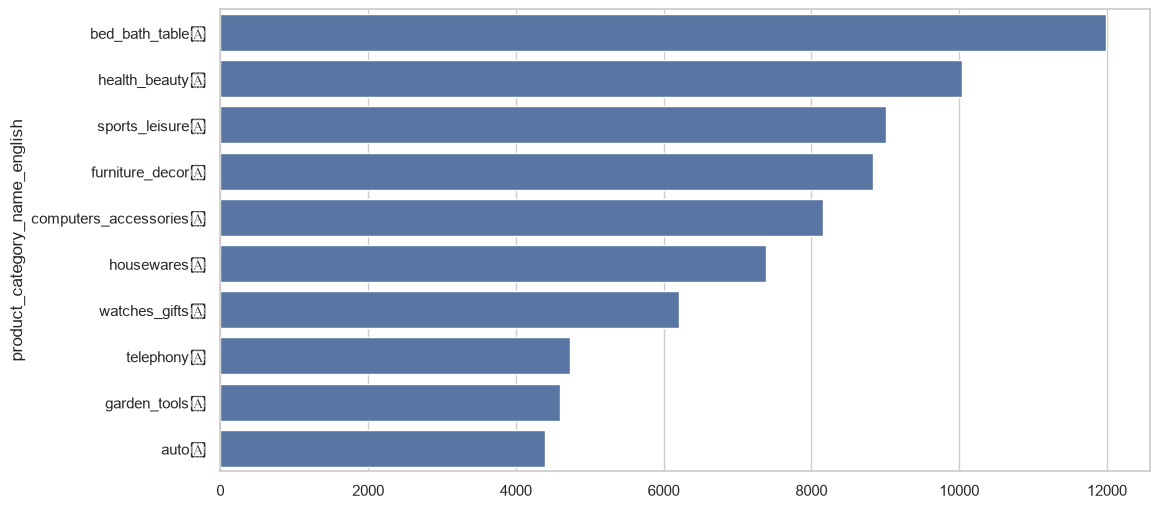

In [26]:
top = df[
"product_category_name_english"
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
x=top.values,
y=top.index
)

plt.show()

In [27]:
monthly = df.groupby(
"order_month_name"
)["payment_value"].sum()

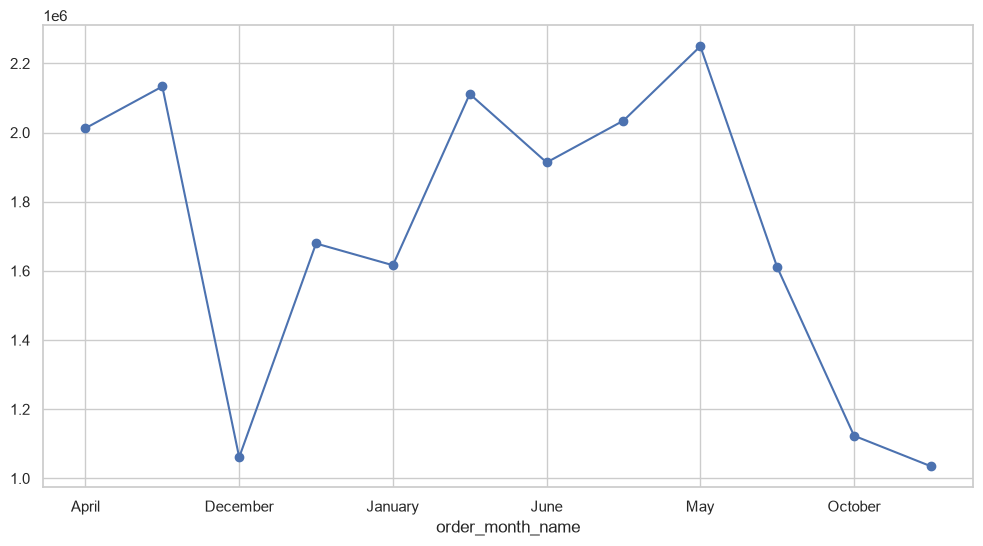

In [28]:
plt.figure(figsize=(12,6))

monthly.plot(
kind="line",
marker="o"
)

plt.show()

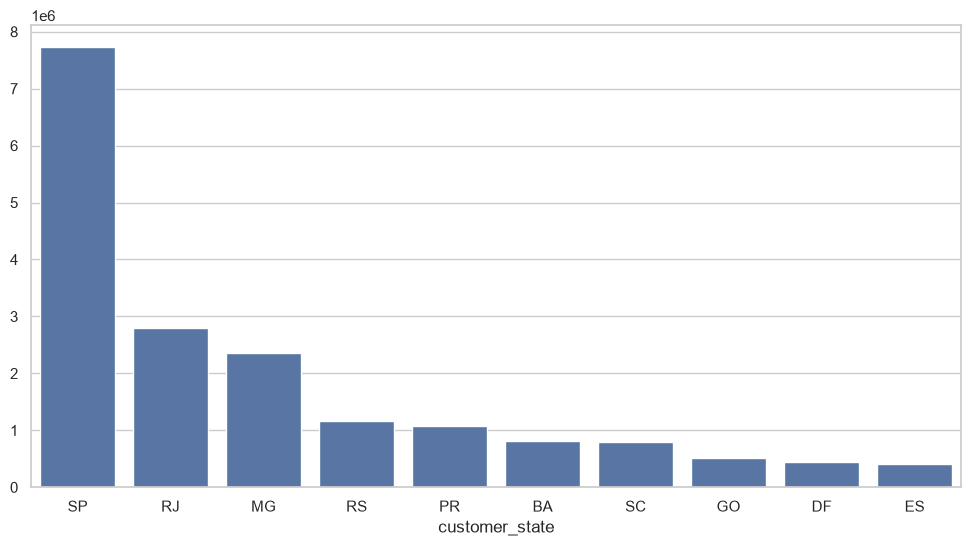

In [29]:
top = df.groupby(
"customer_state"
)["payment_value"].sum()

top = top.sort_values(
ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
x=top.index,
y=top.values
)

plt.show()

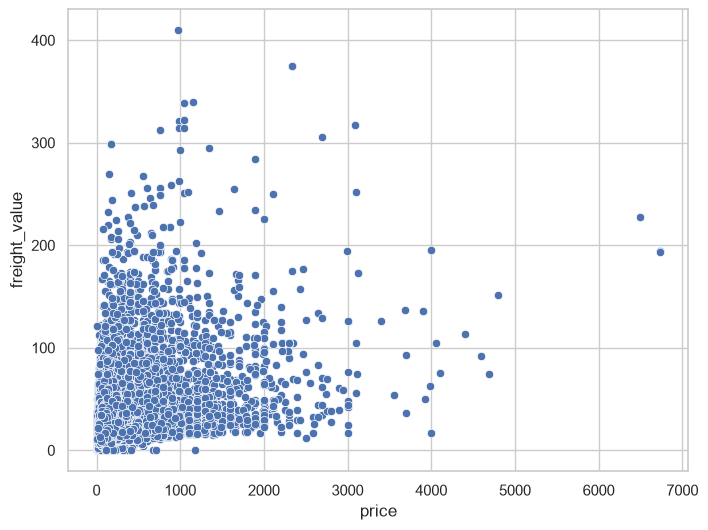

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x="price",
y="freight_value",
data=df
)

plt.show()

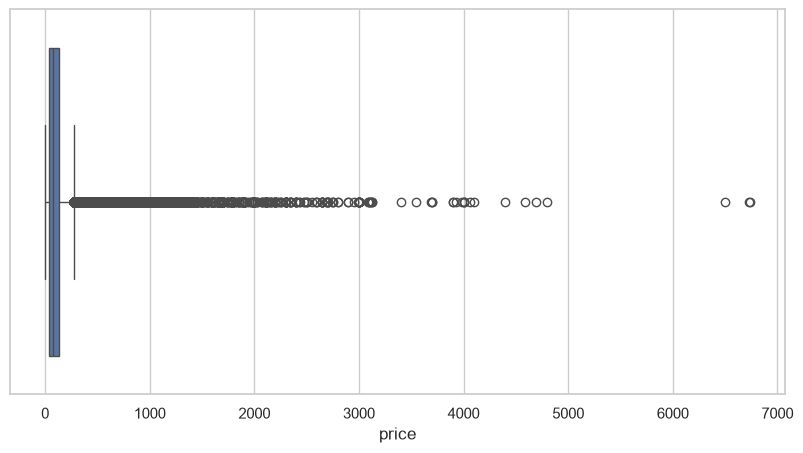

In [31]:
plt.figure(figsize=(10,5))

sns.boxplot(
x=df["price"]
)

plt.show()

Observation

• Most orders are delivered successfully.

• Credit Card is the most used payment method.

• Few product categories contribute the highest revenue.

• Delivery time is concentrated around the average range.

• Price distribution is right-skewed.